# Coefficient field inversion in an elliptic partial differential equation

We consider the estimation of a coefficient in an elliptic partial differential
equation as a model problem. Depending on the interpretation of the unknowns and the
type of measurements, this model problem arises, for instance, in inversion for
groundwater flow or heat conductivity. It can also be interpreted as finding a membrane
with a certain spatially varying stiffness. Let $\Omega\subset\mathbb{R}^n$,
$n\in\{1,2,3\}$ be an open, bounded domain and consider the following problem:

$$
\min_{m} J(m):=\frac{1}{2}\int_\Omega (u-u_d)^2\, dx + \frac{\gamma}{2}\int_\Omega|\nabla m|^2\,dx + \frac{\delta}{2}\int_\Omega m^2\,dx,
$$

where $u$ is the solution of

$$
\begin{aligned}
-\nabla\cdot(\exp(m)\nabla u) &= f \quad \text{in }\Omega,\\
u &= 0 \quad \text{on }\partial\Omega.
\end{aligned}
$$

Here $m\in U_{ad}:=\{m\in H^1(\Omega) \cap L^{\infty}(\Omega)\}$ is the unknown coefficient
field, $u_d$ denotes (possibly noisy) data, $f\in H^{-1}(\Omega)$ a given force, and
$\gamma \ge 0$ the regularization parameter. The small $\delta > 0$ makes the
regularization operator invertible; it does not change the solution visibly, and
hIPPYlib's version of this tutorial, which takes $\delta = 0$, preconditions with the
operator we get at $\delta = \gamma$.

## The variational (or weak) form of the state equation:

Find $u\in H_0^1(\Omega)$ such that

$$(\exp(m)\nabla u,\nabla p) - (f,p) = 0, \text{ for all } p\in H_0^1(\Omega),$$

where $H_0^1(\Omega)$ is the space of functions vanishing on $\partial\Omega$ with square
integrable derivatives, and $(\cdot\,,\cdot)$ denotes the $L^2$ inner product.

## Gradient evaluation:

The Lagrangian functional $\mathscr{L}:H_0^1(\Omega)\times H^1(\Omega)\times H_0^1(\Omega)\rightarrow \mathbb{R}$ is given by

$$
\mathscr{L}(u,m,p):= \frac{1}{2}(u-u_d,u-u_d) + \frac{\gamma}{2}(\nabla m, \nabla m) + \frac{\delta}{2}(m, m) + (\exp(m)\nabla u,\nabla p) - (f,p).
$$

Then the gradient of the cost functional $J(m)$ with respect to the parameter $m$ is

$$
\mathcal{G}(m)(\tilde m) := \gamma(\nabla m, \nabla \tilde{m}) + \delta(m, \tilde m) + (\tilde{m}\exp(m)\nabla u, \nabla p) \quad \forall \tilde{m} \in H^1(\Omega),
$$

where $u \in H_0^1(\Omega)$ is the solution of the forward problem,

$$ \mathscr{L}_p(u,m,p)(\tilde{p}) := (\exp(m)\nabla u, \nabla \tilde{p}) - (f,\tilde{p}) = 0 \quad \forall \tilde{p} \in H_0^1(\Omega), $$

and $p \in H_0^1(\Omega)$ is the solution of the adjoint problem,

$$ \mathscr{L}_u(u,m,p)(\tilde{u}) := (\exp(m)\nabla p, \nabla \tilde{u}) + (u-u_d,\tilde{u}) = 0 \quad \forall \tilde{u} \in H_0^1(\Omega).$$

## Hessian action:

To evaluate the action $\mathcal{H}(m)(\hat{m})$ of the Hessian in a given direction
$\hat{m}$, we consider variations of the meta-Lagrangian functional

$$
\begin{aligned}
\mathscr{L}^H(u,m,p; \hat{u}, \hat{m}, \hat{p}) := {} & \gamma(\nabla m, \nabla \hat{m}) + \delta(m, \hat m) + (\hat{m}\exp(m)\nabla u, \nabla p) && \text{gradient}\\
& + (\exp(m)\nabla u, \nabla \hat{p}) - (f,\hat{p}) && \text{forward eq}\\
& + (\exp(m)\nabla p, \nabla \hat{u}) + (u-u_d,\hat{u}) && \text{adjoint eq}.
\end{aligned}
$$

Then the action of the Hessian in a given direction $\hat{m}$ is

$$
\begin{aligned}
(\tilde{m}, \mathcal{H}(m)(\hat{m}) ) & := \mathscr{L}^H_m(u,m,p; \hat{u}, \hat{m}, \hat{p})(\tilde{m}) \\
& = (\tilde{m} \exp(m) \nabla \hat{u}, \nabla{p}) + \gamma (\nabla \hat{m}, \nabla \tilde{m}) + \delta(\hat m, \tilde m) + (\tilde{m} \hat{m} \exp(m)\nabla u, \nabla p) + (\tilde{m}\exp(m) \nabla u, \nabla \hat{p}) \quad \forall \tilde{m} \in H^1(\Omega),
\end{aligned}
$$

where

- $u\in H^1_0(\Omega)$ and $p \in H^1_0(\Omega)$ are the solution of the forward and adjoint problem, respectively;
- $\hat{u} \in H^1_0(\Omega)$ is the solution of the incremental forward problem,
$$ \mathscr{L}^H_p(u,m,p; \hat{u}, \hat{m}, \hat{p})(\tilde{p}) := (\exp(m) \nabla \hat{u}, \nabla \tilde{p}) + (\hat{m} \exp(m) \nabla u, \nabla \tilde p) = 0 \quad \forall \tilde{p} \in H_0^1(\Omega); $$
- and $\hat{p} \in H^1_0(\Omega)$ is the solution of the incremental adjoint problem,
$$ \mathscr{L}^H_u(u,m,p; \hat{u}, \hat{m}, \hat{p})(\tilde{u}) := (\hat{u}, \tilde{u}) + (\hat{m} \exp(m)\nabla p, \nabla \tilde{u}) + (\exp(m) \nabla \tilde u, \nabla \hat{p}) = 0 \quad \forall \tilde{u} \in H_0^1(\Omega). $$

## Inexact Newton-CG:

Written in abstract form, the Newton method computes an update direction $\hat{m}_k$ by
solving the linear system

$$ (\tilde{m}, \mathcal{H}(m_k)(\hat{m}_k) ) = -\mathcal{G}(m_k)(\tilde m) \quad \forall \tilde{m} \in H^1(\Omega), $$

where the evaluation of the gradient $\mathcal{G}(m_k)$ involves the solution $u_k$ and
$p_k$ of the forward and adjoint problem (respectively) for $m = m_k$. Similarly, the
Hessian action $\mathcal{H}(m_k)(\hat{m}_k)$ requires the additional solution of the
incremental forward and adjoint problems.

## Discrete Newton system:

$
\def\bu{{\bf u}}
\def\bm{{\bf m}}
\def\bp{{\bf p}}
\def\bhu{{\bf \hat u}}
\def\bhm{{\bf \hat m}}
\def\bhp{{\bf \hat p}}
\def\bg{{\bf g}}
\def\bA{{\bf A}}
\def\bC{{\bf C}}
\def\bH{{\bf H}}
\def\bR{{\bf R}}
\def\bW{{\bf W}}
$

Let us denote the vectors corresponding to the discretization of the functions
$u_k, m_k, p_k$ by $\bu_k, \bm_k, \bp_k$ and of the functions $\hat u_k, \hat m_k, \hat p_k$
by $\bhu_k, \bhm_k, \bhp_k$. The discretization of the above system is the symmetric
linear system

$$ \bH_k \, \bhm_k = -\bg_k. $$

The gradient $\bg_k$ is computed in three steps:

- given $\bm_k$, solve the forward problem $\bA_k \bu_k = {\bf f}$, where $\bA_k \bu_k$ stems from the discretization of $(\exp(m_k)\nabla u_k, \nabla \tilde{p})$ and ${\bf f}$ from the right-hand side $f$;
- given $\bm_k$ and $\bu_k$, solve the adjoint problem $\bA_k^T \bp_k = - \bW_{\rm uu}\,(\bu_k-\bu_d)$, where $\bW_{\rm uu}$ is the mass matrix of the $L^2$ inner product in the state space and $\bu_d$ stems from the data;
- define the gradient $\bg_k = \bR \bm_k + \bC_k^T \bp_k$, where $\bR$ stems from the regularization $\gamma ( \nabla \hat{m}, \nabla \tilde{m}) + \delta(\hat m, \tilde m)$, and $\bC_k$ from the term $(\tilde{m}\exp(m_k)\nabla u_k, \nabla p_k)$.

Similarly, the action of the Hessian $\bH_k \, \bhm_k$ in a direction $\bhm_k$ (with CG
we only need its action) is given by

- solving the incremental forward problem $\bA_k \bhu_k = -\bC_k \bhm_k$;
- solving the incremental adjoint problem $\bA_k^T \bhp_k = -(\bW_{\rm uu} \bhu_k + \bW_{\rm um}\,\bhm_k)$, where $\bW_{\rm um}\,\bhm_k$ stems from $(\hat{m}_k \exp(m_k)\nabla p_k, \nabla \tilde{u})$;
- and defining the Hessian action
$$ \bH_k \, \bhm = \underbrace{(\bR + \bW_{\rm mm})}_{\text{Hessian of the regularization}} \bhm + \underbrace{(\bC_k^{T}\bA_k^{-T} (\bW_{\rm uu} \bA_k^{-1} \bC_k - \bW_{\rm um}) - \bW_{\rm mu} \bA_k^{-1} \bC_k)}_{\text{Hessian of the data misfit}}\;\bhm. $$

## What hIPPyMFEM writes for you

In hIPPYlib's version of this tutorial every block above, $\bA$, $\bC$, $\bW_{\rm um}$,
$\bW_{\rm mm}$, is written as its own UFL form. Here none of them is written: they are
derivatives of the single residual density

$$ r(u, m, p; x) = \exp(m)\, \nabla u \cdot \nabla p - f\, p, $$

computed by automatic differentiation at the quadrature points. The `PDEVariationalProblem`
solves with $\bA$ and $\bA^T$ and applies the other blocks through
`apply_ij(i, j, direction, out)`, where `i` and `j` index `STATE`, `PARAMETER` and
`ADJOINT`: $\bC$ is the `(ADJOINT, PARAMETER)` block, $\bW_{\rm um}$ the
`(STATE, PARAMETER)` block, and so on. Only the fixed bilinear forms of the cost, the
mass matrix $\bW_{\rm uu}$ and the regularization $\bR$, are assembled with MFEM's own
integrators.

## Goals:

By the end of this notebook, you should be able to:

- solve the forward and adjoint Poisson equations
- understand the inverse method framework
- visualise and understand the results
- modify the problem and code

## Mathematical tools used:

- Finite element method
- Derivation of gradient and Hessian via the adjoint method
- Inexact Newton-CG
- Armijo line search

## List of software used:

- [MFEM](https://mfem.org) through [PyMFEM](https://github.com/mfem/PyMFEM), a parallel finite element library
- [hypre](https://github.com/hypre-space/hypre), for scalable preconditioners
- [JAX](https://docs.jax.dev), for automatic differentiation
- [Matplotlib](https://matplotlib.org), for plotting the results

## Set up

### Import dependencies

In [1]:
import math
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb, STATE, PARAMETER, ADJOINT

import jax.numpy as jnp

mfem.Hypre.Init()
comm = MPI.COMM_WORLD

### Model set up:

As in the introduction, the first thing we need to do is to set up the numerical model.
In this cell, we set the mesh, the finite element spaces for the state (P2) and the
parameter (P1), the true parameter and the initial guess, the right-hand side, and the
boundary conditions.

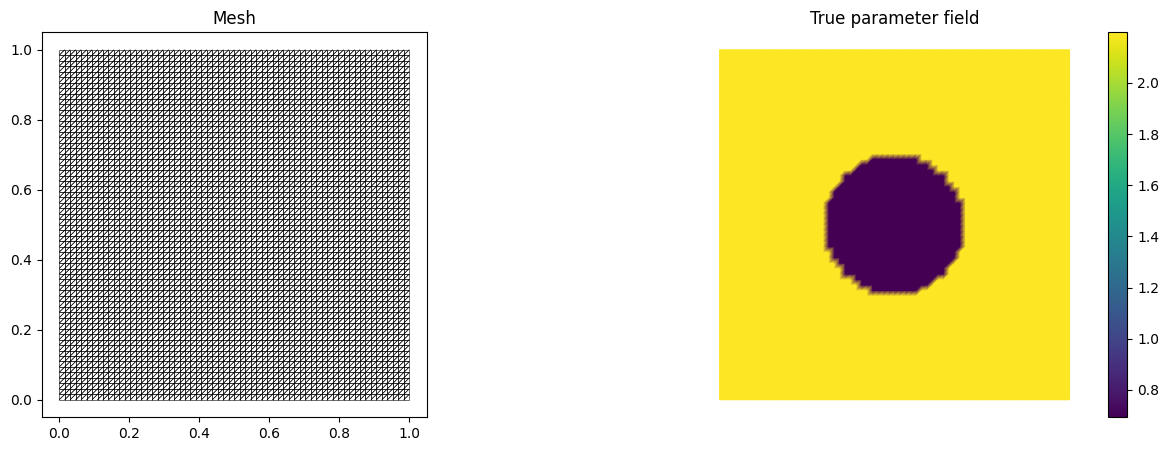

In [2]:
nx = ny = 64
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(nx, ny, mfem.Element.TRIANGLE))
Vm = hm.FunctionSpace.H1(mesh, 1)
Vu = hm.FunctionSpace.H1(mesh, 2)

# the true and the initial parameter
mtrue = Vm.project(lambda x: math.log(2.0 + 7.0 * (math.hypot(x[0] - 0.5, x[1] - 0.5) > 0.2)))
m = Vm.project(lambda x: math.log(2.0))

# the force and the (homogeneous) Dirichlet conditions on the whole boundary
f = 1.0
bc_state = hm.DirichletBC(Vu, 0.0, bdr_attributes="all")
bc_adj = bc_state.homogeneous()

plt.figure(figsize=(15, 5))
nb.plot(mesh, subplot_loc=121, mytitle="Mesh", show_axis="on")
nb.plot(Vm, mtrue, subplot_loc=122, mytitle="True parameter field")
plt.show()

### The forward problem:

One residual density defines the state equation, and with it every derivative block the
inversion needs.

In [3]:
def pde_varf(u, m, p, x):
    return jnp.exp(m.val) * hm.inner(u.grad, p.grad) - f * p.val


pde = hm.PDEVariationalProblem([Vu, Vm, Vu], pde_varf, bc_state, bc_adj, is_fwd_linear=True)
print("dofs: state %d, parameter %d" % (Vu.GlobalTrueVSize(), Vm.GlobalTrueVSize()))

dofs: state 16641, parameter 4225


### Set up synthetic observations:

- Propose a coefficient field $m_{\rm true}$ shown above
- The weak form of the PDE: find $u\in H_0^1(\Omega)$ such that $(\exp(m_{\rm true})\nabla u,\nabla p) - (f,p) = 0$ for all $p\in H_0^1(\Omega)$
- Perturb the solution: $u = u + \eta$, where $\eta \sim \mathcal{N}(0, \sigma^2)$ at every degree of freedom, with $\sigma$ five percent of the largest value of $u$

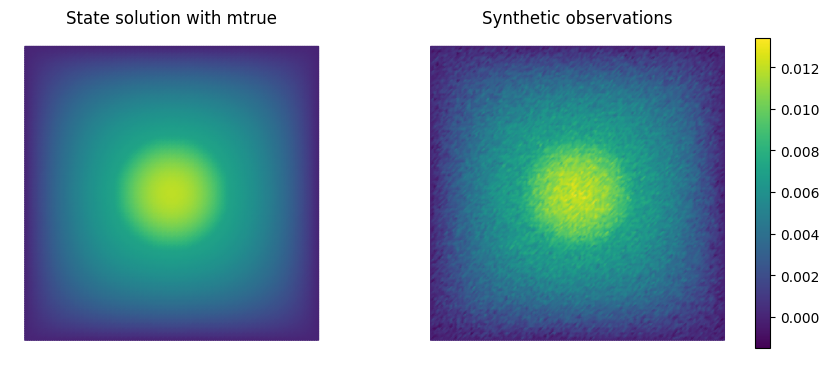

In [4]:
noise_level = 0.05

utrue = pde.generate_state()
pde.solveFwd(utrue, [utrue, mtrue, None])

ud = utrue.copy()
MAX = ud.norm("linf")
noise = pde.generate_state()
hm.parRandom.set_seed(1)
hm.parRandom.normal(noise_level * MAX, noise)
bc_adj.zero(noise)
ud.axpy(1.0, noise)

nb.multi1_plot([(Vu, utrue), (Vu, ud)], ["State solution with mtrue", "Synthetic observations"])
plt.show()

### The cost function evaluation:

$$
J(m):=\underbrace{\frac{1}{2}\int_\Omega (u-u_d)^2\, dx}_{\text{misfit} } + \underbrace{\frac{\gamma}{2}\int_\Omega|\nabla m|^2\,dx + \frac{\delta}{2}\int_\Omega m^2\,dx}_{\text{reg}}
$$

In the code below, $\bW$ and $\bR$ are symmetric positive definite matrices that stem from
the finite element discretization of the misfit and regularization components of the cost
functional, respectively, and $\bf M$ is the mass matrix of the parameter space, used to
turn the gradient into a function. They are fixed bilinear forms, so MFEM's own
integrators assemble them.

In [5]:
gamma = 1e-8
delta = gamma

keep_alive = []          # MFEM keeps raw pointers to coefficients: hold on to them


def assemble(space, diffusion=0.0, mass=0.0):
    # diffusion * (grad v, grad w) + mass * (v, w)
    integrators = []
    if diffusion:
        keep_alive.append(mfem.ConstantCoefficient(diffusion))
        integrators.append(mfem.DiffusionIntegrator(keep_alive[-1]))
    if mass:
        keep_alive.append(mfem.ConstantCoefficient(mass))
        integrators.append(mfem.MassIntegrator(keep_alive[-1]))
    return hm.assemble_native_matrix(space, integrators)


W = assemble(Vu, mass=1.0)                       # misfit weight
R = assemble(Vm, diffusion=gamma, mass=delta)    # regularization
M = assemble(Vm, mass=1.0)                       # L2 inner product on the parameter space


# solvers for the mass matrix (gradient) and for R (preconditioner of the Newton system)
Msolver = hm.KrylovSolver(comm, "cg", "jacobi")
Msolver.set_operator(M)
Rsolver = hm.KrylovSolver(comm, "cg", "amg")
Rsolver.set_operator(R)


def apply(A, x, y):
    A.Mult(x.hypre, y.hypre)
    return y


def cost(u, ud, m):
    diff = u.copy().axpy(-1.0, ud)
    reg = 0.5 * m.inner(apply(R, m, pde.generate_parameter()))
    misfit = 0.5 * diff.inner(apply(W, diff, pde.generate_state()))
    return [reg + misfit, misfit, reg]

### Initial guess

We solve the state equation and compute the cost functional for the initial guess of
the parameter `m_ini`.

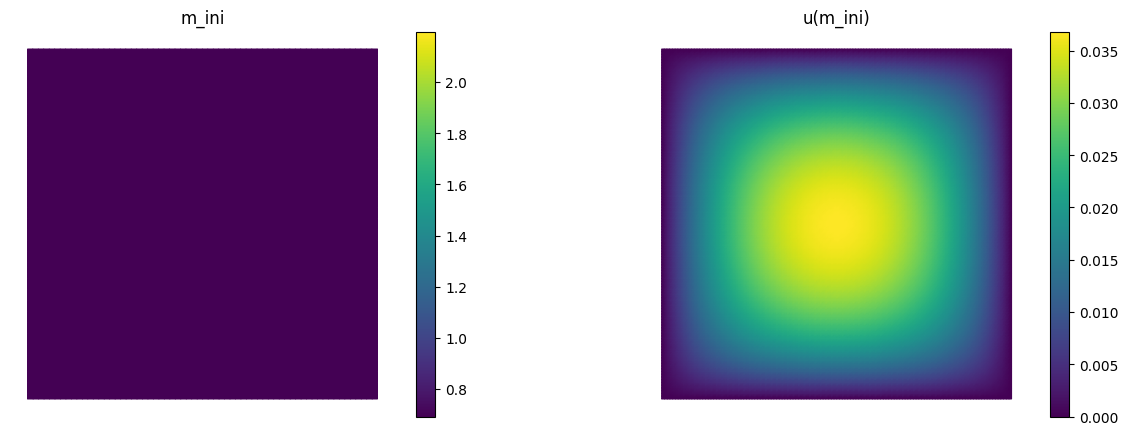

In [6]:
u = pde.generate_state()
p = pde.generate_adjoint()
pde.solveFwd(u, [u, m, None])
[cost_old, misfit_old, reg_old] = cost(u, ud, m)

plt.figure(figsize=(15, 5))
nb.plot(Vm, m, subplot_loc=121, mytitle="m_ini", vmin=mtrue.min(), vmax=mtrue.max())
nb.plot(Vu, u, subplot_loc=122, mytitle="u(m_ini)")
plt.show()

### The reduced Hessian apply to a vector $\bhm$:

Here we describe how to apply the reduced Hessian operator to a vector $\bhm$. For an
appropriate choice of the regularization, the reduced Hessian operator evaluated in a
neighborhood of the solution is positive definite, whereas far from the solution the
reduced Hessian may be indefinite. On the contrary, the Gauss-Newton approximation of
the Hessian is always positive definite.

For this reason, it is beneficial to perform a few initial Gauss-Newton steps (5 in this
particular example) to accelerate the convergence of the inexact Newton-CG algorithm.

The Hessian apply reads:

$$
\begin{aligned}
\bhu &= -\bA^{-1} \bC \bhm & \text{linearized forward}\\
\bhp &= -\bA^{-T} (\bW_{\rm uu} \bhu + \bW_{\rm um}\,\bhm) & \text{adjoint}\\
\bH \bhm &= (\bR + \bW_{\rm mm})\bhm + \bC^T \bhp + \bW_{\rm mu} \bhu.
\end{aligned}
$$

The Gauss-Newton Hessian apply is obtained by dropping the second derivative operators
$\bW_{\rm um}\,\bhm$, $\bW_{\rm mm}\bhm$, and $\bW_{\rm mu} \bhu$:

$$
\begin{aligned}
\bhu &= -\bA^{-1} \bC \bhm & \text{linearized forward}\\
\bhp &= -\bA^{-T} \bW_{\rm uu} \bhu & \text{adjoint}\\
\bH_{\rm GN} \bhm &= \bR \bhm + \bC^T \bhp.
\end{aligned}
$$

`pde.setLinearizationPoint` assembles $\bA$, $\bC$ and (unless Gauss-Newton) the second
order blocks once, at the current $(\bu, \bm, \bp)$; every Hessian action after that is
two linear solves and a few sparse products.

In [7]:
class HessianOperator:
    cgiter = 0

    def __init__(self, pde, R, W, gauss_newton_approx=False):
        self.pde, self.R, self.W = pde, R, W
        self.gauss_newton_approx = gauss_newton_approx
        self.du = pde.generate_state()        # incremental state
        self.dp = pde.generate_adjoint()      # incremental adjoint
        self.rhs = pde.generate_state()
        self.tmp_u = pde.generate_state()
        self.tmp_m = pde.generate_parameter()

    def generate_vector(self, dim=0):         # what CGSolverSteihaug allocates from
        return self.pde.generate_parameter()

    def init_vector(self, x, dim):
        return self.pde.generate_parameter()

    def mult(self, v, y):
        self.cgiter += 1
        pde = self.pde
        # incremental forward: A du = -C v
        pde.apply_ij(ADJOINT, PARAMETER, v, self.rhs)
        self.rhs.scale(-1.0)
        bc_adj.zero(self.rhs)
        pde.solveIncremental(self.du, self.rhs, is_adj=False)
        # incremental adjoint: A^T dp = -(W du + W_um v)
        apply(self.W, self.du, self.rhs)
        if not self.gauss_newton_approx:
            pde.apply_ij(STATE, PARAMETER, v, self.tmp_u)
            self.rhs.axpy(1.0, self.tmp_u)
        self.rhs.scale(-1.0)
        bc_adj.zero(self.rhs)
        pde.solveIncremental(self.dp, self.rhs, is_adj=True)
        # H v = (R + W_mm) v + C^T dp + W_mu du
        apply(self.R, v, y)
        pde.apply_ij(PARAMETER, ADJOINT, self.dp, self.tmp_m)
        y.axpy(1.0, self.tmp_m)
        if not self.gauss_newton_approx:
            pde.apply_ij(PARAMETER, PARAMETER, v, self.tmp_m)
            y.axpy(1.0, self.tmp_m)
            pde.apply_ij(PARAMETER, STATE, self.du, self.tmp_m)
            y.axpy(1.0, self.tmp_m)

## The inexact Newton-CG optimization with Armijo line search:

We solve the constrained optimization problem using the inexact Newton-CG method with
Armijo line search.

The stopping criterion is based on the norm of the gradient, $\|g_{n}\| \leq \tau$.

First, we compute the gradient by solving the state and adjoint equation for the current
parameter $m$, and then substituting the current state $u$, parameter $m$ and adjoint $p$
variables in the weak form expression of the gradient:

$$ (g, \tilde{m}) = \gamma(\nabla m, \nabla \tilde{m}) + \delta(m, \tilde m) + (\tilde{m}\exp(m)\nabla u, \nabla p).$$

Then, we compute the Newton direction $\hat m$ by iteratively solving $\mathcal{H} {\hat m} = -g$.
The Newton system is solved inexactly by early termination of conjugate gradient
iterations via Eisenstat–Walker (to prevent oversolving) and Steihaug (to avoid negative
curvature) criteria.

Finally, the Armijo line search uses backtracking to find $\alpha$ such that a sufficient
reduction in the cost functional is achieved. More specifically, we use backtracking to
find $\alpha$ such that

$$J( m + \alpha \hat m ) \leq J(m) + \alpha c_{\rm armijo} (\hat m,g). $$

In [8]:
# parameters for the optimization
tol = 1e-8
c = 1e-4
maxiter = 12
plot_on = False

# iteration counters
it = 1
total_cg_iter = 0
converged = False

g, m_delta = pde.generate_parameter(), pde.generate_parameter()
MG, CT_p = pde.generate_parameter(), pde.generate_parameter()
adj_rhs = pde.generate_state()
m_prev = m.copy()

print("Nit   CGit   cost          misfit        reg           sqrt(-G*D)    ||grad||       alpha  tolcg")

while it < maxiter and not converged:
    # solve the adjoint problem: A^T p = -W (u - ud)
    apply(W, u.copy().axpy(-1.0, ud), adj_rhs)
    adj_rhs.scale(-1.0)
    bc_adj.zero(adj_rhs)
    pde.solveAdj(p, [u, m, p], adj_rhs)

    # evaluate the gradient: MG = C^T p + R m, g = M^{-1} MG
    pde.evalGradientParameter([u, m, p], CT_p)
    apply(R, m, MG)
    MG.axpy(1.0, CT_p)
    Msolver.solve(g, MG)

    # the norm of the gradient
    gradnorm = math.sqrt(g.inner(MG))

    # the CG tolerance, by the Eisenstat-Walker criterion
    if it == 1:
        gradnorm_ini = gradnorm
    tolcg = min(0.5, math.sqrt(gradnorm / gradnorm_ini))

    # the Hessian at the current point (Gauss-Newton for the first five steps)
    gauss_newton = it < 6
    pde.setLinearizationPoint([u, m, p], gauss_newton_approx=gauss_newton)
    Hess_Apply = HessianOperator(pde, R, W, gauss_newton_approx=gauss_newton)

    solver = hm.CGSolverSteihaug(hm.CGSolverSteihaug_ParameterList(), comm)
    solver.set_operator(Hess_Apply)
    solver.set_preconditioner(Rsolver)
    solver.parameters["rel_tolerance"] = tolcg
    solver.parameters["zero_initial_guess"] = True
    solver.parameters["print_level"] = -1

    # solve the Newton system H m_delta = -MG
    minus_MG = MG.copy()
    minus_MG.scale(-1.0)
    solver.solve(m_delta, minus_MG)
    total_cg_iter += Hess_Apply.cgiter

    # line search
    alpha = 1.0
    descent = False
    no_backtrack = 0
    m_prev.assign(m)
    while not descent and no_backtrack < 10:
        m.axpy(alpha, m_delta)

        # solve the state/forward problem
        pde.solveFwd(u, [u, m, None])

        # evaluate the cost
        [cost_new, misfit_new, reg_new] = cost(u, ud, m)

        # check the Armijo condition
        if cost_new < cost_old + alpha * c * MG.inner(m_delta):
            cost_old = cost_new
            descent = True
        else:
            no_backtrack += 1
            alpha *= 0.5
            m.assign(m_prev)

    # sqrt(-G * D)
    graddir = math.sqrt(-MG.inner(m_delta))

    print("%2d %6d   %8.5e   %8.5e   %8.5e   %8.5e   %8.5e   %5.2f  %5.3e"
          % (it, Hess_Apply.cgiter, cost_new, misfit_new, reg_new, graddir, gradnorm, alpha, tolcg))

    if plot_on:
        nb.multi1_plot([(Vm, m), (Vu, u), (Vu, p)], ["m", "u", "p"], same_colorbar=False)
        plt.show()

    # check for convergence
    if gradnorm < tol and it > 1:
        converged = True
        print("Newton's method converged in", it, "iterations")
        print("Total number of CG iterations:", total_cg_iter)

    it += 1

if not converged:
    print("Newton's method did not converge in", maxiter, "iterations")

Nit   CGit   cost          misfit        reg           sqrt(-G*D)    ||grad||       alpha  tolcg


 1      1   1.12883e-05   1.12778e-05   1.05026e-08   1.56544e-02   3.79452e-04    1.00  5.000e-01
 2      1   8.02961e-07   7.84286e-07   1.86751e-08   4.68187e-03   5.35002e-05    1.00  3.755e-01


 3      1   3.35836e-07   3.13888e-07   2.19480e-08   9.69834e-04   7.13765e-06    1.00  1.372e-01


 4      4   2.14442e-07   1.64135e-07   5.03072e-08   4.59188e-04   1.01481e-06    1.00  5.171e-02
 5      1   2.08823e-07   1.58089e-07   5.07340e-08   1.06060e-04   6.36514e-07    1.00  4.096e-02


 6     10   2.01747e-07   1.37941e-07   6.38059e-08   1.20812e-04   2.39085e-07    1.00  2.510e-02


 7      4   2.01664e-07   1.39113e-07   6.25511e-08   1.27481e-05   4.47538e-08    1.00  1.086e-02


 8     11   2.01663e-07   1.39229e-07   6.24336e-08   1.73953e-06   3.45788e-09    1.00  3.019e-03
Newton's method converged in 8 iterations
Total number of CG iterations: 33


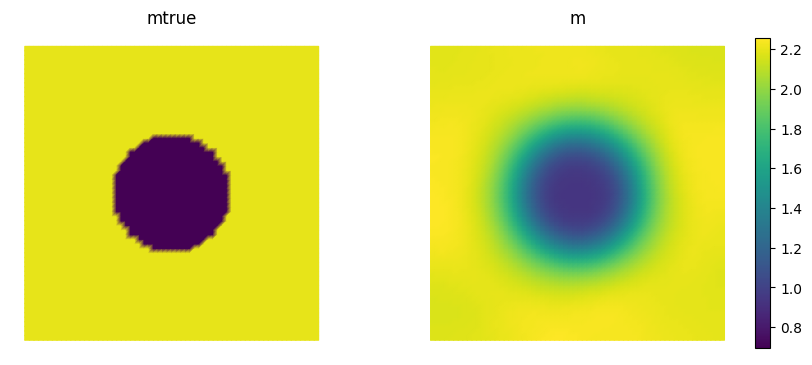

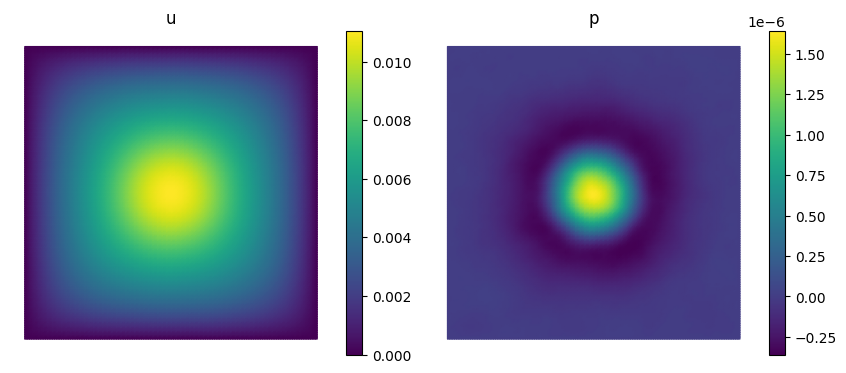

In [9]:
nb.multi1_plot([(Vm, mtrue), (Vm, m)], ["mtrue", "m"])
nb.multi1_plot([(Vu, u), (Vu, p)], ["u", "p"], same_colorbar=False)
plt.show()

## The same inversion with the library

Everything written above by hand is what `hm.Model` and `hm.ReducedSpaceNewtonCG`
provide, and the next tutorials use them directly. A `Model` combines three pieces:

- the PDE, which we already have;
- the regularization, here `hm.LaplacianPrior`, whose precision operator is exactly our $\bR = \gamma \mathbf{K} + \delta \mathbf{M}$ (tutorial 3 replaces it by a proper Gaussian prior);
- the misfit, here `hm.ContinuousStateObservation`, the weighted $L^2$ norm $\frac{1}{2}(\bu - \bu_d)^T \bW (\bu - \bu_d)$, with the rows of the boundary conditions removed.

Before optimizing, `hm.modelVerify` checks the gradient and the Hessian action against
finite differences in a random direction. The gradient error must decay at first order in
the step $h$; so must the error of the Hessian action, since that is the finite difference
of the gradient.
Below $h \approx 10^{-6}$ both errors grow again: the differences are then dominated by
round-off, as for any finite difference, which is why the observed order is read from
the steps above that.

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  7.923551e-05  1.076559e-07  2.054244e-04             -


 5.00e-01  4.018230e-05  5.353090e-08  1.446074e-04        0.9796


 2.50e-01  2.017312e-05  2.836243e-08  1.287232e-04        0.9941


 1.25e-01  1.009547e-05  1.458343e-08  1.245237e-04        0.9987


...

 3.73e-09  1.232995e-08  2.103744e-10  1.228436e-04       -0.9493


 1.86e-09  2.694735e-08  4.213274e-10  1.228436e-04       -1.1280


 9.31e-10  5.431950e-08  8.444769e-10  1.228436e-04       -1.0113


 4.66e-10  9.532680e-08  1.674462e-09  1.228436e-04       -0.8114



observed order: gradient 1.00, Hessian 1.00


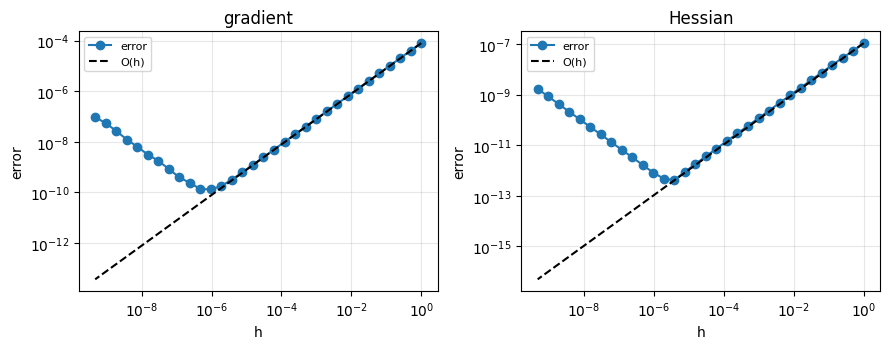

In [10]:
prior = hm.LaplacianPrior(Vm, gamma, delta)
misfit = hm.ContinuousStateObservation(Vu, bcs=bc_adj, data=ud, noise_variance=1.0)
model = hm.Model(pde, prior, misfit)

m0 = Vm.project(lambda x: math.log(2.0))
eps, err_grad, err_H = hm.modelVerify(model, m0, verbose=True, plotting=True)
print("\nobserved order: gradient %.2f, Hessian %.2f"
      % (hm.best_slope(eps, err_grad), hm.best_slope(eps, err_H)))
plt.show()

In [11]:
parameters = hm.ReducedSpaceNewtonCG_ParameterList()
parameters["rel_tolerance"] = 1e-12
parameters["abs_tolerance"] = tol
parameters["max_iter"] = maxiter
parameters["GN_iter"] = 5
parameters["globalization"] = "LS"
parameters["print_level"] = 0

newton = hm.ReducedSpaceNewtonCG(model, parameters)
x = newton.solve([None, m0, None])

print("\n%s after %d iterations and %d CG iterations"
      % (newton.termination_reasons[newton.reason], newton.it, newton.total_cg_iter))
print("cost: by hand %.8e, library %.8e" % (cost_old, newton.final_cost))
d = x[PARAMETER].copy().axpy(-1.0, m)
print("relative difference between the two parameter fields: %.2e" % (d.norm("l2") / m.norm("l2")))


 It cg_it            cost          misfit             reg          (g,dm)          ||g||          alpha          tolcg


  1     1    1.128831e-05    1.127781e-05    1.050258e-08   -2.450604e-04   3.794520e-04   1.000000e+00   5.000000e-01


  2     1    8.029609e-07    7.842858e-07    1.867509e-08   -2.191993e-05   5.350023e-05   1.000000e+00   3.754909e-01


  3     1    3.358363e-07    3.138883e-07    2.194802e-08   -9.405787e-07   7.137646e-06   1.000000e+00   1.371510e-01


  4     4    2.144421e-07    1.641349e-07    5.030722e-08   -2.108535e-07   1.014808e-06   1.000000e+00   5.171464e-02


  5     1    2.088230e-07    1.580890e-07    5.073397e-08   -1.124881e-08   6.365139e-07   1.000000e+00   4.095676e-02


  6    10    2.017466e-07    1.379408e-07    6.380586e-08   -1.459550e-08   2.390853e-07   1.000000e+00   2.510141e-02


  7     4    2.016645e-07    1.391133e-07    6.255114e-08   -1.625128e-10   4.475381e-08   1.000000e+00   1.086017e-02



Norm of the gradient less than tolerance after 7 iterations and 22 CG iterations
cost: by hand 2.01662947e-07, library 2.01664460e-07
relative difference between the two parameter fields: 5.35e-04


The library stops one iteration earlier: it tests the gradient at the new point after
each step, while the loop above tests it before taking the next one, so the loop takes
one more step and ends with a cost lower by less than one part in $10^5$. The parameter
fields differ by a few parts in $10^4$ for a reason that has nothing to do with the
solvers: with $\gamma = 10^{-8}$ the cost is nearly flat along directions the data barely
inform, so a change in the cost that small moves the parameter noticeably there. Tutorial 3
replaces this weak regularization by a prior, and quantifies exactly that uncertainty.

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `02_PoissonDeterministic`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).